# Feature-set enrichment

A well-level profile is hundreds to thousands of features. Reading them one by one is hopeless, and a single column rarely carries a biological claim on its own.

`tl.enrich` scores biologically meaningful *sets* of features instead: a channel (one organelle stain), a measurement family, or a custom prior network. The answer is which *kinds* of measurement moved, not a list of columns, so a result reads at the level a screener reasons at.

It wraps decoupler {cite:p}`Badia_i_Mompel_2022`, so the same call scores sets derived from the feature names and sets that come from prior knowledge.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

# Palette shared with the mantispy plotters:
ACCENT = "crimson"  # the strongly-moved / significant set to report
NULL = "grey"  # background / not significant

## From wells to a scored panel

The preparation is the one from [Normalize, select, aggregate](../profiles/normalize_and_select.ipynb): plate-wise robust normalization, then drop the features flagged as degenerate, which have no spread in some plate and would otherwise dominate every score.


In [2]:
adata = mt.ds.bbbc021()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate")
adata = adata[:, ~adata.var["degenerate_scale"]].copy()

# Keep the treatments that carry a mechanism label; DMSO and unannotated wells are dropped.
treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
treated = treated[treated.obs["Metadata_MOA"].notna().to_numpy()].copy()

{
    "features kept": int(adata.n_vars),
    "treated wells": int(treated.n_obs),
    "mechanisms": int(treated.obs["Metadata_MOA"].nunique()),
}

<path>:2: UserWarning: 3 of 467 features have no spread in at least one group of 'Metadata_Plate'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate")


{'features kept': 464, 'treated wells': 302, 'mechanisms': 12}

## Scoring feature-set activity

`by="channel"` groups the features by the organelle stain they were measured in, so each set is one channel. `method="ulm"` fits a linear model per set and writes the per-well scores to `obsm["score_ulm"]`, a wells-by-channels frame. Averaging those scores within each mechanism says which channels each mechanism moved.


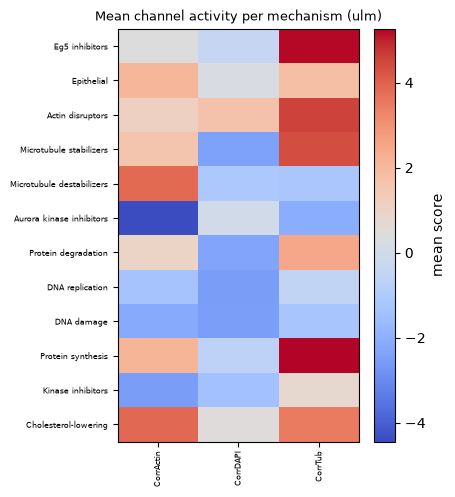

In [3]:
mt.tl.enrich(treated, by="channel", method="ulm")

ax = mt.pl.sets_heatmap(treated, groupby="Metadata_MOA", score_key="score_ulm")
ax.set_title("Mean channel activity per mechanism (ulm)", fontsize=9)
plt.show()

The signed map shows its strongest, cleanest signal for Eg5 inhibitors and protein synthesis on the tubulin channel (CorrTub), and Aurora kinase inhibitors read strongly negative on the actin channel (CorrActin). Several mechanisms are cross-talky, and the signed mean score can be muted when a channel gains and loses features at once: the DNA-damaging mechanisms (DNA damage, DNA replication) stay muted and slightly negative across all three channels rather than lighting up a single DNA block. For a specific mechanism the permutation view below is the better read.

Read the off-target channels honestly. Morphology channels are cross-talky: a microtubule drug rounds the cell, and rounding moves the actin channel as well, so the actin score rises without actin being the drug's target. A channel is an interpretable summary of where the profile moved, not a one-to-one label for the process that moved it.

## The method suite and a robust consensus

`enrich` exposes decoupler's set scorers through `method=`: `ulm`, `mlm`, `ora`, `aucell`, `gsea`, `gsva`, `zscore`, `waggr` and `viper`. They differ in how they turn a set's features into one score, so a call that only one of them supports is a call to distrust. Scoring the same channel sets with two unrelated methods, a linear model and a z-score, shows where they agree.


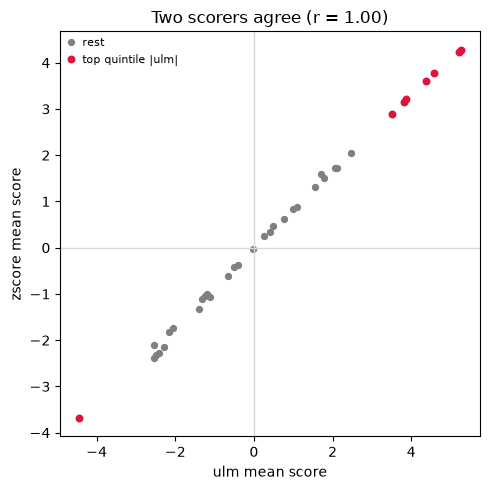

In [4]:
mt.tl.enrich(treated, by="channel", method="ulm")
ulm = treated.obsm["score_ulm"].copy()

mt.tl.enrich(treated, by="channel", method="zscore")
zscore = treated.obsm["score_zscore"].copy()


def mean_per_mechanism(scores):
    """Average each score column within a mechanism of action."""
    grouped = scores.copy()
    grouped["Metadata_MOA"] = treated.obs["Metadata_MOA"].astype(str).to_numpy()
    return grouped.groupby("Metadata_MOA").mean()


ulm_means = mean_per_mechanism(ulm)
zscore_means = mean_per_mechanism(zscore)

channels = ulm_means.columns.intersection(zscore_means.columns)
x = ulm_means[channels].to_numpy().ravel()
y = zscore_means[channels].to_numpy().ravel()
strong = np.abs(x) >= np.quantile(np.abs(x), 0.8)
r = np.corrcoef(x, y)[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(0, color="0.85", lw=1)
ax.axvline(0, color="0.85", lw=1)
ax.scatter(x[~strong], y[~strong], s=18, color=NULL, label="rest")
ax.scatter(x[strong], y[strong], s=22, color=ACCENT, label="top quintile |ulm|")
ax.set(xlabel="ulm mean score", ylabel="zscore mean score", title=f"Two scorers agree (r = {r:.2f})")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The two scorers place the same channels at the extremes, and every strongly-moved set sits in the same quadrant under both, so the sign of the call does not depend on which model produced it. The disagreements are all near zero, where the ranking carries no claim.

That agreement is what `method="consensus"` automates. It runs a panel of these scorers and consolidates their calls, so no single method's bias decides the result.


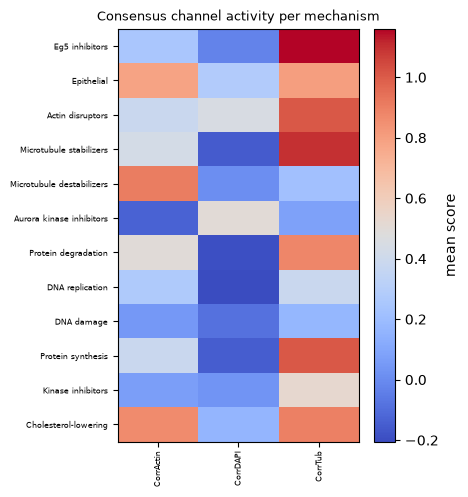

In [5]:
mt.tl.enrich(treated, by="channel", method="consensus")

ax = mt.pl.sets_heatmap(treated, groupby="Metadata_MOA", score_key="score_consensus")
ax.set_title("Consensus channel activity per mechanism", fontsize=9)
plt.show()

The consensus map keeps the strong blocks from the single-method map and damps the entries that only one scorer reported. Prefer it for the call you report; reach for a single method when you specifically need its p-value or its speed. When the methods already agree, the consensus says nothing new, which is the point: the reported call no longer rides on the one scorer you happened to pick.

## Calibrated significance with permutation nulls

The parametric `padj` a method reports assumes its score has a known null distribution. When that assumption is shaky, `n_permutations` replaces it with an empirical two-sided p-value: the set membership is shuffled that many times, and each observed score is ranked against the scores the shuffles produce. The significance then lives in `obsm["padj_ulm"]`.


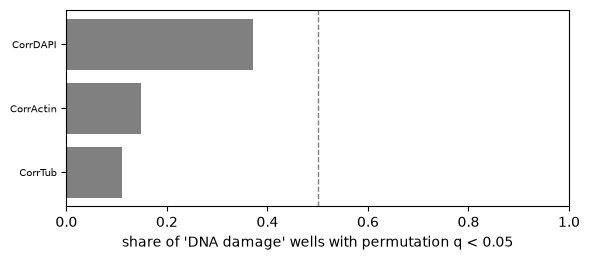

In [6]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="you are shuffling")
    mt.tl.enrich(treated, by="channel", method="ulm", n_permutations=200)

mechanism = "DNA damage"
in_mechanism = treated.obs["Metadata_MOA"].astype(str).to_numpy() == mechanism
significant = (treated.obsm["padj_ulm"][in_mechanism] < 0.05).mean(axis=0).sort_values()

fig, ax = plt.subplots(figsize=(6, 0.4 * len(significant) + 1.5))
colours = np.where(significant.to_numpy() >= 0.5, ACCENT, NULL)
ax.barh(np.arange(len(significant)), significant.to_numpy(), color=colours)
ax.set_yticks(np.arange(len(significant)), significant.index, fontsize=7)
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set(xlabel=f"share of '{mechanism}' wells with permutation q < 0.05", xlim=(0, 1))
fig.tight_layout()
plt.show()

For DNA damage the DNA channel (CorrDAPI) is significant in the most wells, about 37 percent, two to three times more than the cross-talky cytoskeletal channels (CorrActin at 15 percent, CorrTub at 11 percent). No channel clears the 0.5 line, so none is significant in a majority of wells, but the ranking is the expected biology: DNA damage hits the nucleus. The permutation null recovers that organelle ranking even where the single-well signed score does not, and it reads significance off the shuffled sets themselves, which is the safer test when the parametric assumptions are unclear.

## Custom prior sets

`enrich` scores any network with `source`, `target` and `weight` columns, where `source` names a set and `target` a feature in it. `feature_sets` returns exactly that shape, so a set can be built once and passed straight to `enrich(net=...)`.


In [7]:
net = mt.tl.feature_sets(treated, by="channel")
net.head()

,source,target,weight
0,CorrActin,Cells_Intensity_IntegratedIntensityEdge_CorrActin,1.0
1,CorrTub,Cells_Intensity_IntegratedIntensityEdge_CorrTub,1.0
2,CorrActin,Cells_Intensity_IntegratedIntensity_CorrActin,1.0
3,CorrTub,Cells_Intensity_IntegratedIntensity_CorrTub,1.0
4,CorrActin,Cells_Intensity_LowerQuartileIntensity_CorrActin,1.0


Three columns, `source`, `target` and `weight`, are the whole contract. Any curated set in this shape, a pathway, a measurement family, or a literature signature, scores through the same `enrich` call by way of `net=`. Building a biologically curated network is beyond this page; the point here is that the interface does not care where the sets came from.


## Summary

- `enrich` turns a wide profile into a handful of interpretable activity scores, one per feature set, at the level of organelles and measurement families.
- Channels are an interpretable summary, not a clean process label: morphology channels cross-talk, so read the off-target scores with that in mind.
- `method="consensus"` runs a panel and consolidates it, so the reported call does not depend on a single scorer's bias.
- `n_permutations` swaps the parametric significance for an empirical one that does not assume the score's null, the safer test when the assumptions are unclear.
- Any `source`/`target`/`weight` network drops into `net=`, so a curated prior scores through the same call as the feature-derived sets.

See also [Which measurements moved](../phenotypes/which_features_moved.ipynb), which reads the same feature annotation at the level of individual measurement families.
